## Evaluate ERA-Interim Cross validation


In [1]:
import os
import sys


import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2, calc_anomaly

fig_dir = os.path.sep.join([base_dir, 'figures_transf', 'ERAI'])
os.makedirs(fig_dir, exist_ok=True)

In [2]:
def calc_smoothed_climatology(_ds, rolling_window=15, time_dim='time'):
    """
    Calculate smoothed climatology using a rolling mean with specified window size.
    """
    
    window_size = 15
    
    if time_dim == 'month_day':
        month_day = _ds.month_day.values
        time_index = pd.to_datetime('1980-' + month_day + ' 12:00', format='%Y-%m-%d %H:%M', errors='coerce')
        _ds = _ds.assign_coords(time=('month_day', time_index)).swap_dims({'month_day': 'time'})

    # add padding at beginning and end to avoid edge effects
    time = _ds['time'].values
    dt = time[1] - time[0]
    period = time[-1] - time[0] + dt
    padding_size = window_size // 2
    left_slice = slice(-padding_size, None)
    right_slice = slice(0, padding_size)
    left = _ds.isel({'time': left_slice}).copy()
    right = _ds.isel({'time': right_slice}).copy()
    left_time = left['time'].values - period
    right_time = right['time'].values + period
    left = left.assign_coords({'time': left_time})
    right = right.assign_coords({'time': right_time})

    ds_padded = xr.concat([left, _ds, right], dim='time')

    ds_clim_15 = ds_padded.rolling(time=rolling_window, center=True, min_periods=rolling_window).mean()
    ds_clim_15 = ds_clim_15.sel(time=time) # remove padding

    # set all years to a common leap year (e.g., 1980) to have valid datetime index
    ti = pd.to_datetime(ds_clim_15['time'].values) 
    new_ti = ti.map(lambda t: t.replace(year=1980)) 
    ds_clim_15 = ds_clim_15.assign_coords(time=('time', new_ti))


    return   ds_clim_15


In [3]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM_stabilized'])
pred_dir = '/dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM/'

# # load climatology of true melt
# ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
# #ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'CESM2', 'HIRHAM5', 'firnpack', 'climat_1990-2013_smoothed15.nc']))
# snmel_clim = ds_clim['snmel']#.sel(x=ds_pred['x'], y=ds_pred['y'])
# snmel_clim


ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013.nc']))
ds_clim_15 = calc_smoothed_climatology(ds_clim, rolling_window=15)
snmel_clim = ds_clim_15['snmel']
snmel_clim

<xarray.DataArray 'snmel' (time: 366, y: 602, x: 402)> Size: 354MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(366, 602, 402), dtype=float32)
Coordinates:
    lon      (y, x) float32 968kB -47.29 -47.22 -47.15 ... 43.28 43.58 43.88
    lat      (y, x) float32 968kB 54.32 54.34 54.36 54.39 ... 85.75 85.71 85.66
  * time     (time) datetime64[ns] 3kB 1980-01-01T12:00:00 ... 1980-12-31T12:...
Dimensions without coordinates: y, x
Attributes:
    long_name:  Acc snow melt
    units:      mm/day weq
    height:     0.0
    time:       365.75

In [ ]:
# def calc_anomaly(ds, clim):
#     md_clim = clim['time'].dt.strftime('%m-%d')        # DataArray of strings length 366
#     clim = clim.assign_coords(md=md_clim)              # attach md coordinate to the DataArray

#     # 2. group by the md coordinate and average (should give one value per md per spatial point)
#     clim = clim.groupby('md').mean(dim='time')   # dims: ('md', spatial...)

#     # 3. prepare the main data: build md for every day; map 02-29 -> 02-28 if desired
#     # da = ds_melt.set_index(z=['y', 'x']).unstack('z').transpose('time', 'y', 'x')

#     md_data = ds['time'].dt.strftime('%m-%d')
#     #md_data_fixed = md_data.where(md_data != '02-29', other='02-28')  # simple leap-day treatment
#     ds = ds.assign_coords(md=('time', md_data.values))         # attach md coord to data

#     # 4. subtract: groupby on md aligns with clim_by_md's md coordinate; broadcasting happens automatically
#     anomaly = (ds.groupby('md') - clim).compute()

#     return anomaly, clim, ds

In [ ]:
# # predict anomalies for 2016 w.r.t. climatology 1990-2013

# ds_clim = ds_clim.sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int))

# pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31')).compute()
# true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31')).compute()

# anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'])
# anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'])

## Basin-wise Scores of Modular NN

In [4]:

valyears = range(1992, 2017, 2) #range(2000, 2015, 2)
appliedyears = range(1990, 2017) #[1990, 1991]
iter_n = range(5)
scaling_factor = 1.796553703424 / 58391 

metrics = ['total melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([valyears, iter_n, appliedyears], names=['valyear', 'iter', 'appliedyear'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in valyears:
    data_dir = os.path.sep.join([pred_dir, f'fold_{year}', 'pred_data.zarr'])
    print(f'Load data {data_dir} ...')
    with xr.open_dataset(data_dir).chunk(chunking) as ds:
        for it in iter_n:
            ds_true = ds['snmel_true']
            try:
                
                ds_pred_it = ds['snmel_pred'].sel(iteration=it)
                for ay in appliedyears:
                    pred_da = ds_pred_it.sel(time=slice(f"{ay}-01-01", f"{ay}-12-31")).compute()
                    true_da = ds_true.sel(time=slice(f"{ay}-01-01", f"{ay}-12-31")).compute()

                    residual = pred_da - true_da
                    total_melt = true_da.sum(dim=['time','x','y']).item()*scaling_factor
                    df_per_year.loc[(year,it,ay), 'total melt'] = total_melt
                    df_per_year.loc[(year,it,ay), 'RMSE'] = get_rmse(residual)
                    df_per_year.loc[(year,it,ay), 'MAE'] = get_mae(residual)
                    df_per_year.loc[(year,it,ay), 'MBE'] = get_mbe(residual)
                    df_per_year.loc[(year,it,ay), 'R2'] = get_r2(true_da.values, pred_da.values)

                    #print('Calculate anomalies')
                    anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'].sel(x=ds_pred_it['x'].astype(int), y=ds_pred_it['y'].astype(int)))
                    anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'].sel(x=ds_pred_it['x'].astype(int), y=ds_pred_it['y'].astype(int)))
                    df_per_year.loc[(year,it,ay), 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
            except Exception as e:
                print(e)

display(df_per_year.round(2))

Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_1992/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_1994/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_1996/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_1998/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_2000/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_2002/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_2004/pred_data.zarr ...
Load data /dmidata/projects/smb_and_polar_rcm/elkesc/output/Crossval/crossval_ERAI_modularNNEBM//fold_2006/pred_data.z

total melt  RMSE   MAE   MBE    R2  R2_anomalies
valyear iter appliedyear                                                  
1992    0    1990             576.28  0.84  0.18  0.03  0.96          0.83
             1991             547.18  0.84  0.18  0.05  0.96          0.84
             1992             293.63  0.90  0.16  0.12  0.90          0.86
             1993             570.15  0.75  0.17  0.05  0.97          0.85
             1994             475.81  0.74  0.16  0.07  0.96          0.86
...                              ...   ...   ...   ...   ...           ...
2016    4    2012            1058.76  0.90  0.21 -0.01  0.98          0.93
             2013             510.18  0.86  0.15  0.05  0.95          0.80
             2014             650.19  0.80  0.15  0.03  0.97          0.87
             2015             610.86  0.94  0.18  0.08  0.95          0.83
             2016             725.53  0.87  0.17  0.02  0.97          0.86

[1755 rows x 6 columns]

In [5]:
df_per_year.to_csv(os.path.sep.join([pred_dir, 'metrics_per_year.csv']))

## Scores aggregations

In [23]:
# models evaluated on the separate year; variance shows only the effect of the random seed
stats = df_per_year.groupby(level=['valyear','appliedyear']).agg(['mean', 'std'])
display(stats.round(2))

total melt       RMSE         MAE         MBE          R2  \
                          mean  std  mean   std  mean   std  mean   std  mean   
valyear appliedyear                                                             
2012    1990            576.28  0.0  0.86  0.03  0.16  0.02 -0.01  0.03  0.96   
        1991            547.18  0.0  0.86  0.03  0.16  0.02  0.00  0.02  0.96   
2014    1990            576.28  0.0  0.91  0.01  0.17  0.01 -0.03  0.02  0.96   
        1991            547.18  0.0  0.89  0.02  0.16  0.01 -0.03  0.02  0.95   

                         R2_anomalies      
                     std         mean std  
valyear appliedyear                        
2012    1990         0.0          NaN NaN  
        1991         0.0          NaN NaN  
2014    1990         0.0          NaN NaN  
        1991         0.0          NaN NaN

In [6]:
# models evaluated across all the years together; variance shows how the performance metric depends on the year that we test on; i.e. sensitivity of the 
# testing itself w.r.t. climate state
stats = df_per_year.groupby(level=['valyear', 'iter']).agg(['mean', 'std'])
display(stats.round(2))

total melt          RMSE         MAE         MBE          R2  \
                   mean     std  mean   std  mean   std  mean   std  mean   
valyear iter                                                                
1992    0        620.68  140.61  0.86  0.08  0.19  0.02  0.07  0.04  0.96   
        1        620.68  140.61  0.84  0.08  0.15  0.02  0.05  0.03  0.96   
        2        620.68  140.61  0.84  0.07  0.15  0.02  0.04  0.03  0.96   
        3        620.68  140.61  0.84  0.07  0.15  0.02  0.03  0.03  0.96   
        4        620.68  140.61  0.83  0.07  0.15  0.02  0.04  0.03  0.96   
...                 ...     ...   ...   ...   ...   ...   ...   ...   ...   
2016    0        620.68  140.61  0.82  0.09  0.14  0.03 -0.04  0.03  0.97   
        1        620.68  140.61  0.83  0.09  0.15  0.02 -0.01  0.03  0.96   
        2        620.68  140.61  0.82  0.08  0.14  0.02 -0.02  0.03  0.97   
        3        620.68  140.61  0.82  0.09  0.15  0.02  0.00  0.03  0.97   
        4        620.68  140.61  0.83  0.08  0.15  0.02  0.01  0.03  0.96   

                   R2_anomalies        
               std         mean   std  
valyear iter                           
1992    0     0.01         0.85  0.04  
        1     0.01         0.86  0.04  
        2     0.01         0.86  0.03  
        3     0.01         0.86  0.03  
        4     0.01         0.86  0.03  
...            ...          ...   ...  
2016    0     0.01         0.87  0.03  
        1     0.01         0.87  0.03  
        2     0.01         0.87  0.03  
        3     0.01         0.87  0.03  
        4     0.01         0.86  0.03  

[65 rows x 12 columns]

In [7]:
# each year modeled by all the models; variance shows the difference of the model performances per year; i.e. sensitivity w.r.t. training data (and seed)
stats = df_per_year.groupby(level=['appliedyear']).agg(['mean', 'std'])
display(stats.round(2))

total melt       RMSE         MAE         MBE          R2        \
                  mean  std  mean   std  mean   std  mean   std  mean   std   
appliedyear                                                                   
1990            576.28  0.0  0.88  0.05  0.16  0.02 -0.02  0.04  0.96  0.01   
1991            547.18  0.0  0.87  0.04  0.16  0.02 -0.01  0.04  0.96  0.00   
1992            293.63  0.0  0.75  0.06  0.11  0.02  0.06  0.03  0.93  0.01   
1993            570.15  0.0  0.77  0.04  0.15  0.02 -0.01  0.04  0.96  0.00   
1994            475.81  0.0  0.72  0.04  0.13  0.02  0.01  0.03  0.96  0.00   
1995            626.42  0.0  1.03  0.08  0.19  0.02 -0.06  0.04  0.95  0.01   
1996            455.79  0.0  0.79  0.03  0.14  0.02  0.01  0.03  0.95  0.00   
1997            519.11  0.0  0.76  0.05  0.14  0.02 -0.01  0.04  0.96  0.00   
1998            709.09  0.0  0.84  0.06  0.18  0.02 -0.03  0.05  0.97  0.00   
1999            545.88  0.0  0.75  0.04  0.14  0.02  0.01  0.04  0.97  0.00   
2000            548.03  0.0  0.77  0.04  0.14  0.02  0.02  0.04  0.97  0.00   
2001            501.83  0.0  0.76  0.03  0.14  0.02  0.02  0.04  0.96  0.00   
2002            685.66  0.0  0.93  0.06  0.18  0.02 -0.04  0.05  0.96  0.01   
2003            732.46  0.0  0.98  0.07  0.19  0.02 -0.05  0.05  0.96  0.01   
2004            595.81  0.0  0.84  0.04  0.16  0.02  0.01  0.04  0.96  0.00   
2005            723.45  0.0  0.87  0.05  0.18  0.02 -0.00  0.05  0.97  0.00   
2006            592.13  0.0  0.83  0.04  0.16  0.02  0.04  0.04  0.96  0.00   
2007            740.14  0.0  0.88  0.05  0.18  0.02  0.01  0.05  0.97  0.00   
2008            723.04  0.0  0.83  0.05  0.17  0.02  0.01  0.05  0.97  0.00   
2009            571.46  0.0  0.85  0.05  0.16  0.02  0.05  0.04  0.96  0.00   
2010            797.38  0.0  0.92  0.05  0.19  0.02 -0.00  0.05  0.97  0.00   
2011            672.01  0.0  0.87  0.04  0.17  0.02  0.04  0.05  0.97  0.00   
2012           1058.76  0.0  0.94  0.06  0.23  0.03 -0.02  0.06  0.98  0.00   
2013            510.18  0.0  0.87  0.04  0.16  0.02  0.05  0.04  0.95  0.00   
2014            650.19  0.0  0.83  0.04  0.16  0.02  0.03  0.05  0.97  0.00   
2015            610.86  0.0  0.97  0.07  0.19  0.02  0.07  0.05  0.95  0.01   
2016            725.53  0.0  0.87  0.04  0.18  0.02  0.02  0.05  0.97  0.00   

            R2_anomalies        
                    mean   std  
appliedyear                     
1990                0.81  0.02  
1991                0.82  0.02  
1992                0.91  0.01  
1993                0.84  0.02  
1994                0.86  0.01  
1995                0.82  0.03  
1996                0.87  0.01  
1997                0.88  0.01  
1998                0.86  0.02  
1999                0.88  0.01  
2000                0.90  0.01  
2001                0.86  0.01  
2002                0.85  0.02  
2003                0.85  0.02  
2004                0.83  0.02  
2005                0.88  0.01  
2006                0.89  0.01  
2007                0.86  0.02  
2008                0.89  0.01  
2009                0.84  0.02  
2010                0.87  0.02  
2011                0.83  0.02  
2012                0.93  0.01  
2013                0.79  0.02  
2014                0.86  0.01  
2015                0.82  0.03  
2016                0.86  0.01

In [8]:
stats_all = df_per_year.agg(['mean', 'std'])
stats_all

,total melt,RMSE,MAE,MBE,R2,R2_anomalies
mean,620.676470,0.851443,0.163952,0.007315,0.962401,0.857827
std,138.021367,0.091235,0.031326,0.053710,0.009564,0.035276


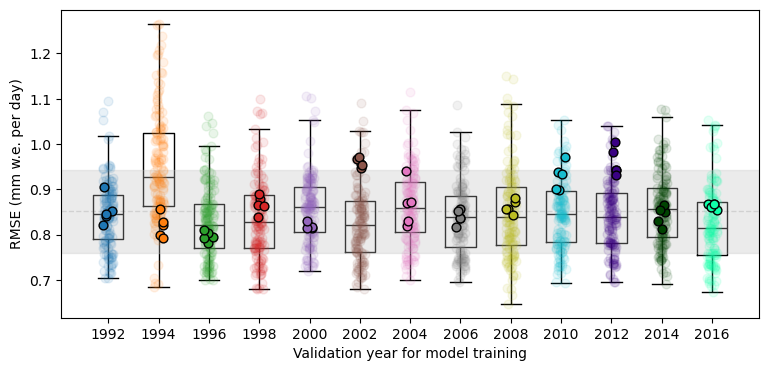

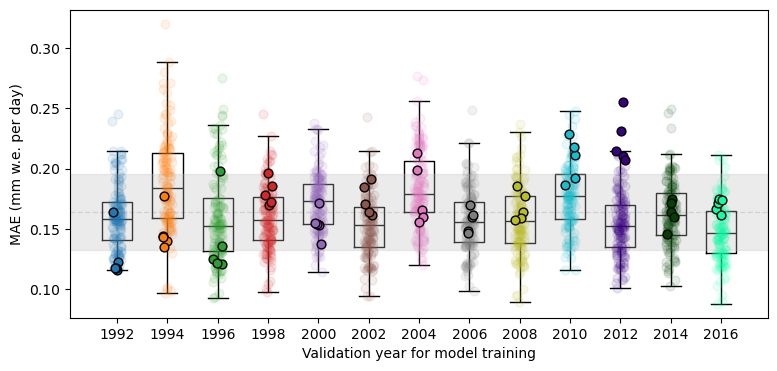

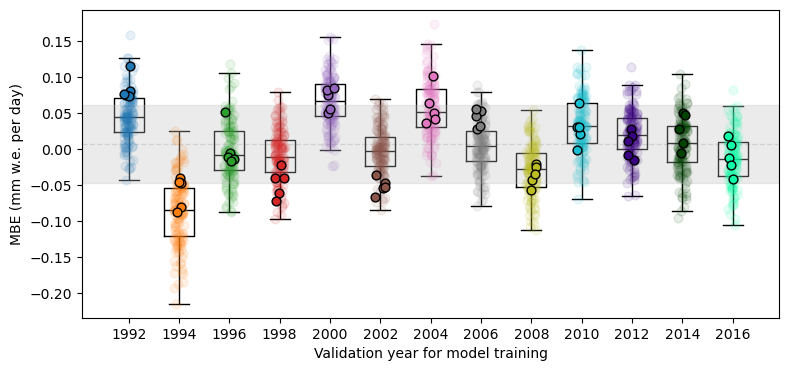

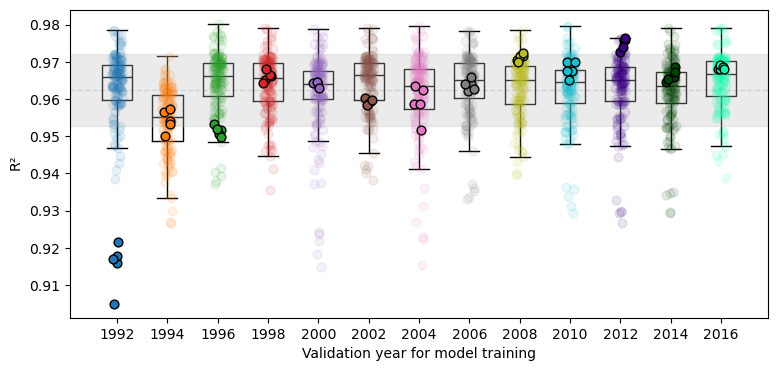

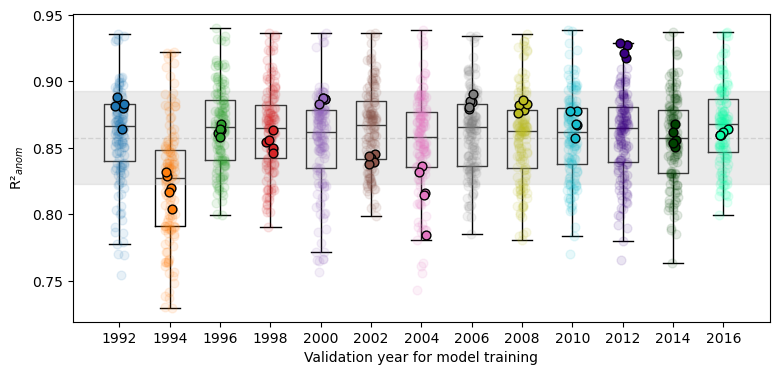

In [51]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.6, linestyle='--', linewidth=1, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.3)
    for i,bb in enumerate(valyears):
        dff = df_per_year.xs(bb, level='valyear')[metric_to_plot]
        
        # vp = ax.violinplot(dff.values, positions=[i], widths=0.6, showmedians=False, showextrema=False)
        # for pc in vp['bodies']:
        #     pc.set_facecolor(colors[i])
        #     pc.set_alpha(0.3)  # 0.5 = 50% transparent
        vp = sns.boxplot(dff.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)

        dff_train = dff[dff.index.get_level_values('appliedyear') != bb]
        plt.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], alpha=0.1)

        dff_val = dff[dff.index.get_level_values('appliedyear') == bb]
        plt.scatter((np.random.rand(len(dff_val)))*0.2+i-0.1, dff_val.values, s=40, color=colors[i], edgecolor='k', linewidth=1)

        ax.set_xticks(np.arange(len(valyears)))
        ax.set_xticklabels(valyears)

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Validation year for model training')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_per_model_{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

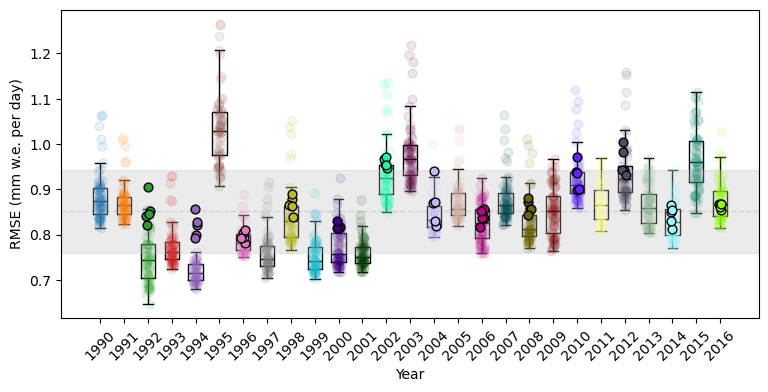

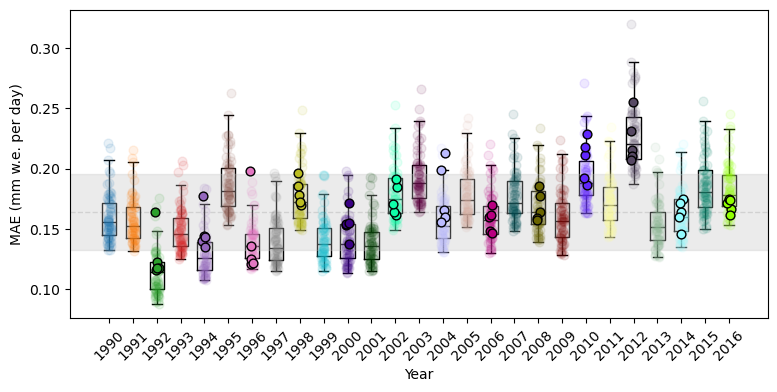

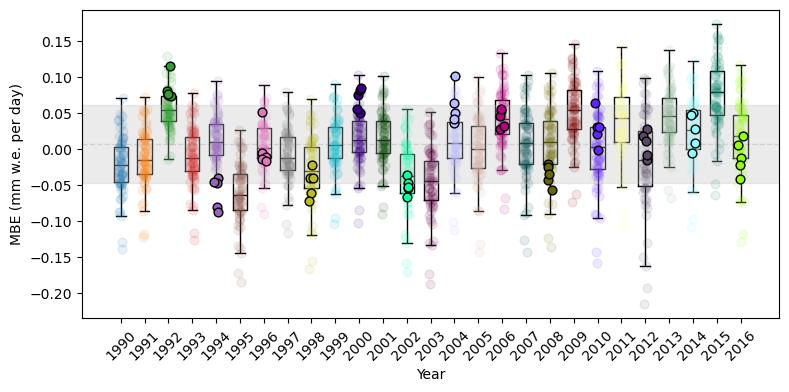

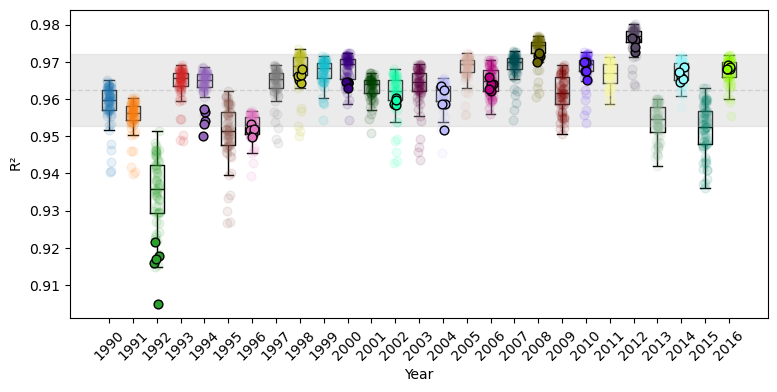

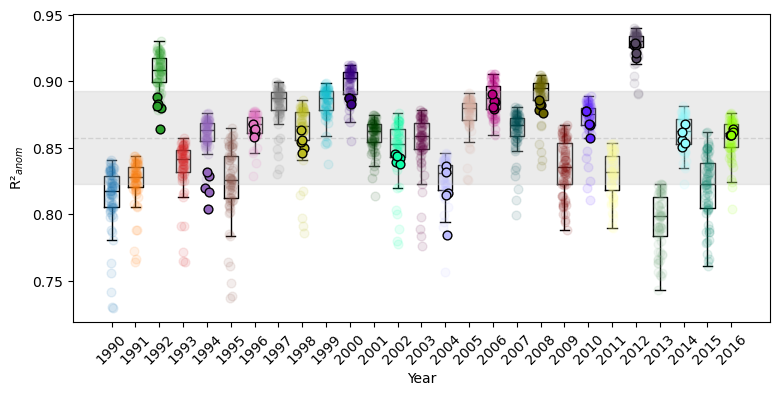

In [52]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.6, linestyle='--', linewidth=1, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.3)
    for i,bb in enumerate(appliedyears):
        dff = df_per_year.xs(bb, level='appliedyear')[metric_to_plot]

        # vp = ax.violinplot(dff.values, positions=[i], widths=0.6, showmedians=False, showextrema=False)
        # for pc in vp['bodies']:
        #     pc.set_facecolor(colors[i])
        #     pc.set_alpha(0.3)  # 0.5 = 50% transparent
        vp = sns.boxplot(dff.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)

        dff_train = dff[dff.index.get_level_values('valyear') != bb]
        plt.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], alpha=0.1)

        dff_val = dff[dff.index.get_level_values('valyear') == bb]
        plt.scatter((np.random.rand(len(dff_val)))*0.2+i-0.1, dff_val.values, s=40, color=colors[i], edgecolor='k', linewidth=1)

        ax.set_xticks(np.arange(len(appliedyears)))
        ax.set_xticklabels(appliedyears, rotation=45)

        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Year')
        
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_per_year_{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()